In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\karth\Downloads\youtube_ad_revenue_dataset.csv")

In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [5]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [6]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [7]:
df.nunique()

video_id                  5000
date                       365
views                      736
likes                     1855
comments                   466
watch_time_minutes      114000
video_length_minutes    120000
subscribers             113254
category                     6
device                       4
country                      6
ad_revenue_usd          120000
dtype: int64

In [8]:
df.isna().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [9]:
df["likes"] = df["likes"].fillna(df["likes"].mean())

In [10]:
df["comments"] = df["comments"].fillna(df["comments"].mean())

In [11]:
df["watch_time_minutes"] = df["watch_time_minutes"].fillna(df["watch_time_minutes"].median())

In [12]:
df["likes"] = df["likes"].astype(int)

In [13]:
df["comments"] = df["comments"].astype(int)

In [14]:
df["date"] = pd.to_datetime(df["date"])

In [15]:
df.duplicated().sum()

np.int64(2400)

In [16]:
df.duplicated(subset=["video_id"]).sum()

np.int64(117400)

In [17]:
df = df.drop_duplicates(subset=["video_id"])

to identify the outliers


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

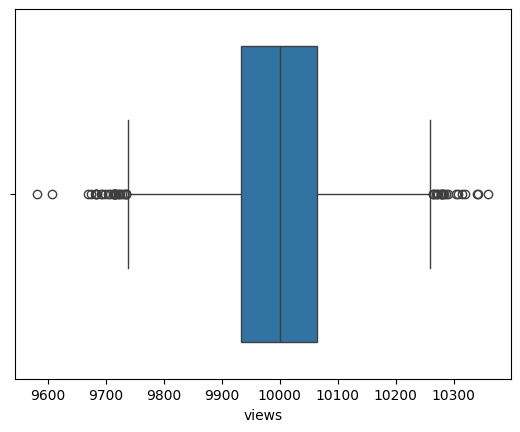

In [19]:
sns.boxplot(x=df["views"])
plt.show()

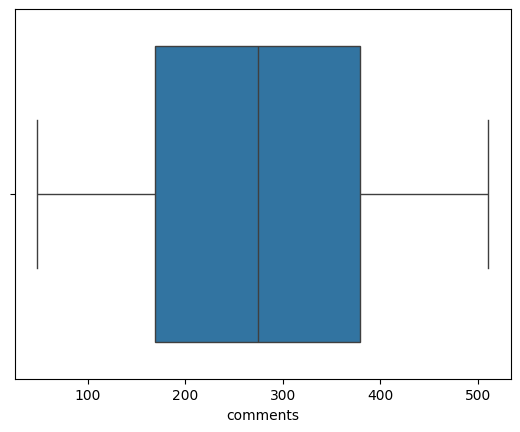

In [20]:
sns.boxplot(x=df["comments"])
plt.show()

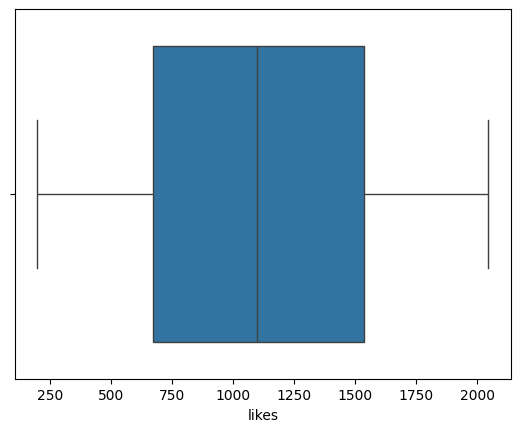

In [21]:
sns.boxplot(x=df["likes"])
plt.show()

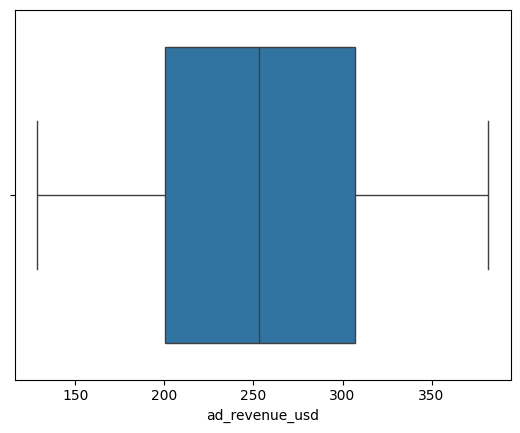

In [22]:
sns.boxplot(x=df["ad_revenue_usd"])
plt.show()

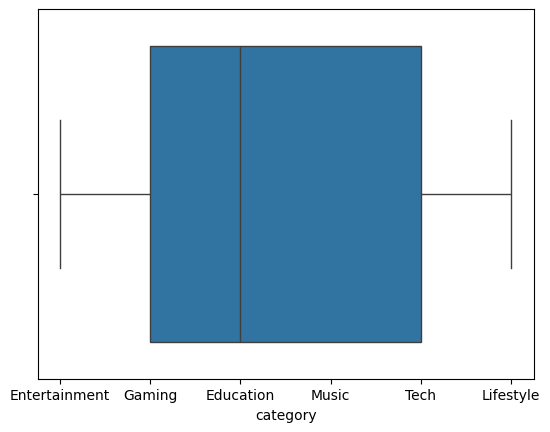

In [23]:
sns.boxplot(x=df["category"])
plt.show()

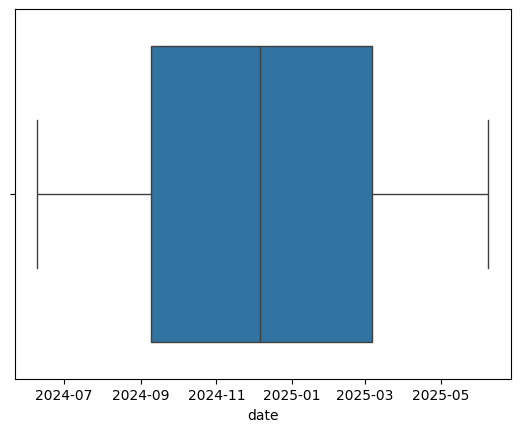

In [24]:
sns.boxplot(x=df["date"])
plt.show()

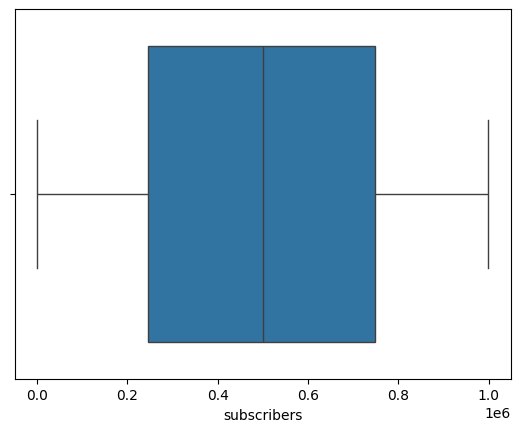

In [25]:
sns.boxplot(x=df["subscribers"])
plt.show()

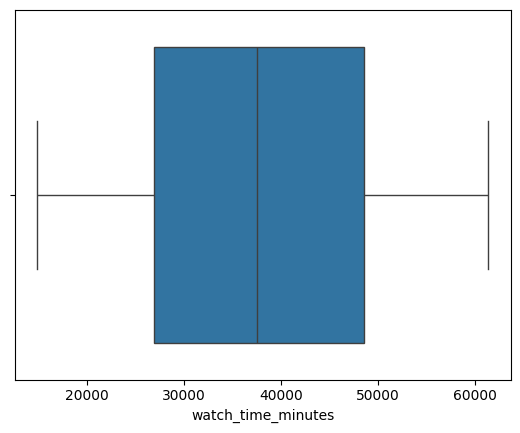

In [26]:
sns.boxplot(x=df["watch_time_minutes"])
plt.show()

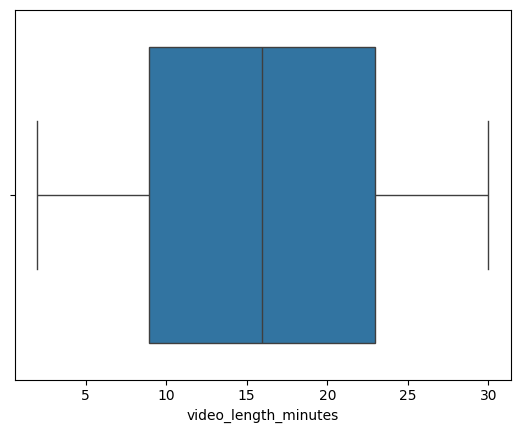

In [27]:
sns.boxplot(x=df["video_length_minutes"])
plt.show()

In [28]:
Q1 = df["views"].quantile(0.25)
Q3 = df["views"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [29]:
df = df[(df["views"] >= lower_bound) & (df["views"] <= upper_bound)]

In [30]:
df = df[(df["views"] >= lower_bound) | (df["views"] <= upper_bound)]

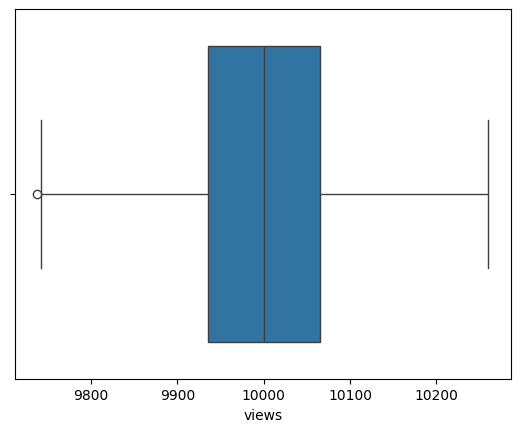

In [31]:
sns.boxplot(x=df["views"])
plt.show()

EDA process


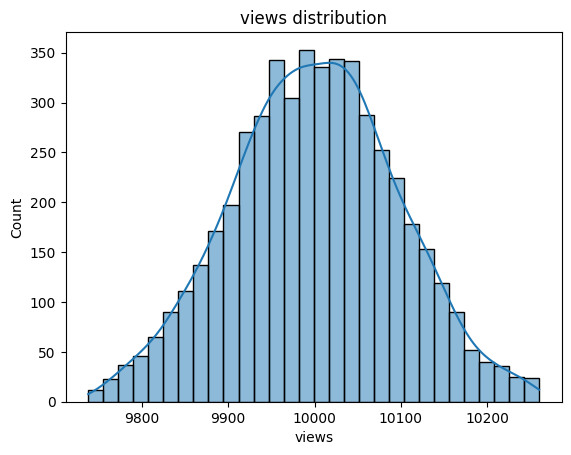

In [32]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.histplot(df["views"], bins=30, kde=True)
plt.title("views distribution")
plt.show()

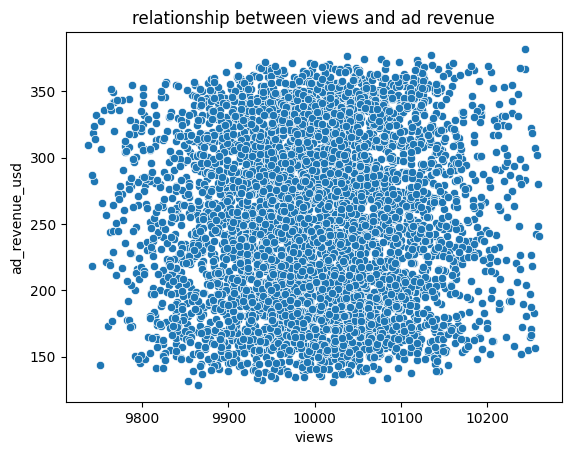

In [33]:
sns.scatterplot(x=df["views"], y=df["ad_revenue_usd"])
plt.title("relationship between views and ad revenue")
plt.xlabel("views")
plt.ylabel("ad_revenue_usd")
plt.show()

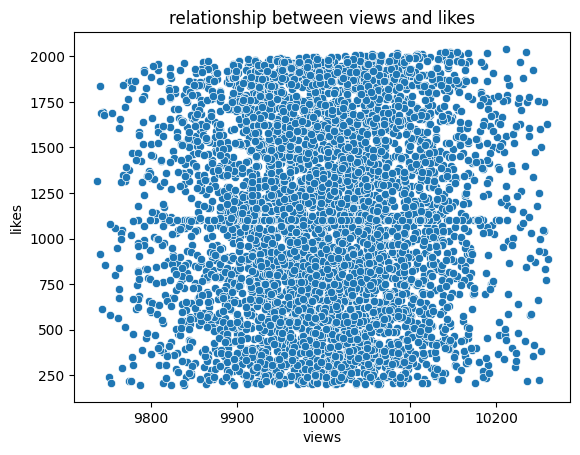

In [34]:
sns.scatterplot(x=df["views"],y=df["likes"])
plt.title("relationship between views and likes")
plt.xlabel("views")
plt.ylabel("likes")
plt.show()

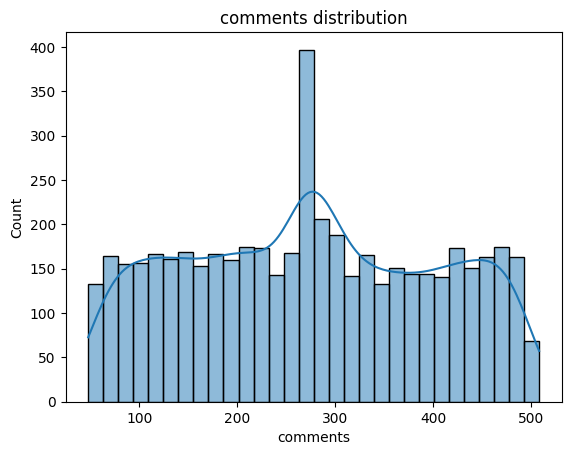

In [35]:
sns.histplot(df["comments"], bins= 30, kde=True)
plt.title("comments distribution")
plt.show()

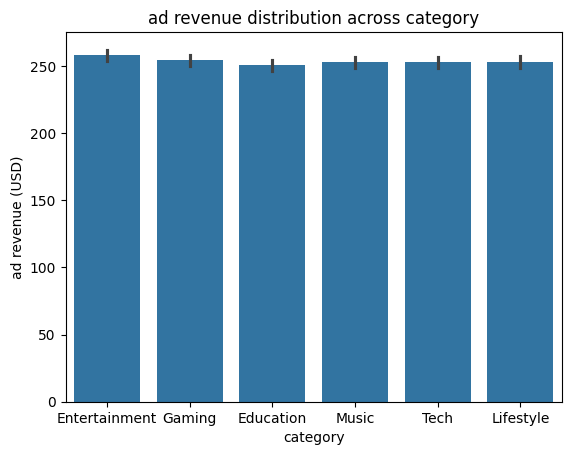

In [36]:
sns.barplot(x=df["category"],y=df["ad_revenue_usd"])
plt.title("ad revenue distribution across category")
plt.xlabel("category")
plt.ylabel("ad revenue (USD)")
plt.show()

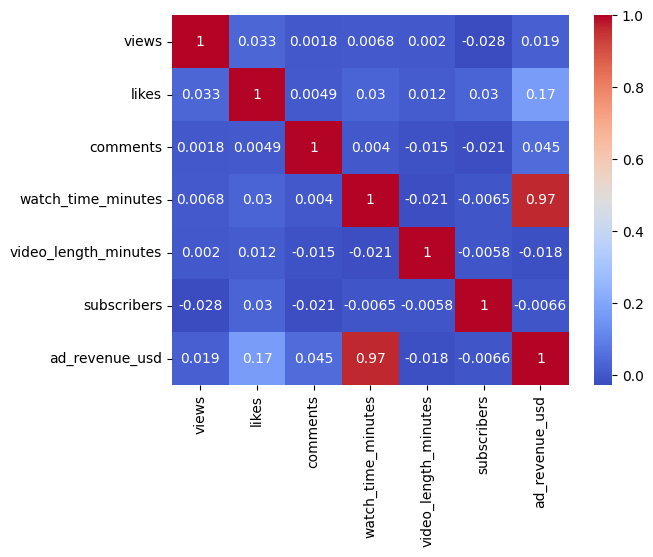

In [37]:
sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True, cmap="coolwarm")
plt.show()

In [38]:
df["engagement_rate"] = df["likes"] + df["comments"] / df["views"]

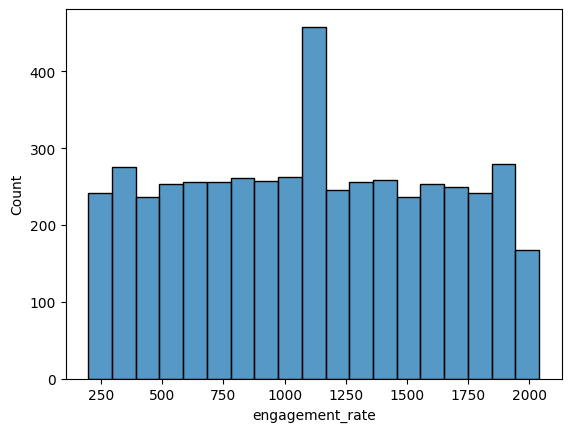

In [39]:
sns.histplot(df["engagement_rate"])
plt.show()

In [40]:
df.sort_values("views" , ascending=False).head(10)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
3033,vid_4397,2024-10-19 10:50:40.993199,10260,890,409,35041.960687,23.681591,460399,Tech,TV,US,240.991577,890.039864
12750,vid_1533,2024-11-23 10:50:40.993199,10259,1629,332,40871.099598,21.195234,848603,Lifestyle,Desktop,AU,279.846077,1629.032362
19182,vid_1982,2024-08-15 10:50:40.993199,10258,773,247,37656.516104,21.908785,879774,Education,Desktop,DE,248.512300,773.024079
2948,vid_316,2024-10-27 10:50:40.993199,10257,834,442,48114.932530,16.826593,419729,Lifestyle,Tablet,CA,302.213629,834.043093
722,vid_3481,2025-01-01 10:50:40.993199,10256,1751,471,32035.338381,8.688143,304976,Gaming,Mobile,AU,242.659833,1751.045924
3761,vid_3291,2024-07-03 10:50:40.993199,10255,927,268,17540.953822,14.877362,257012,Gaming,Mobile,AU,156.668919,927.026134
2900,vid_2911,2025-02-23 10:50:40.993199,10255,1040,267,49020.569011,29.438320,967817,Gaming,Desktop,AU,307.005672,1040.026036
4026,vid_4733,2024-08-08 10:50:40.993199,10254,1045,477,21948.116321,12.106329,162646,Lifestyle,Desktop,AU,183.061698,1045.046518
5788,vid_3918,2024-12-13 10:50:40.993199,10252,1504,425,49131.626357,4.017780,491413,Education,Mobile,UK,318.204157,1504.041455
5032,vid_4300,2024-06-21 10:50:40.993199,10252,384,107,33159.581497,12.421047,699313,Gaming,Tablet,US,218.187969,384.010437


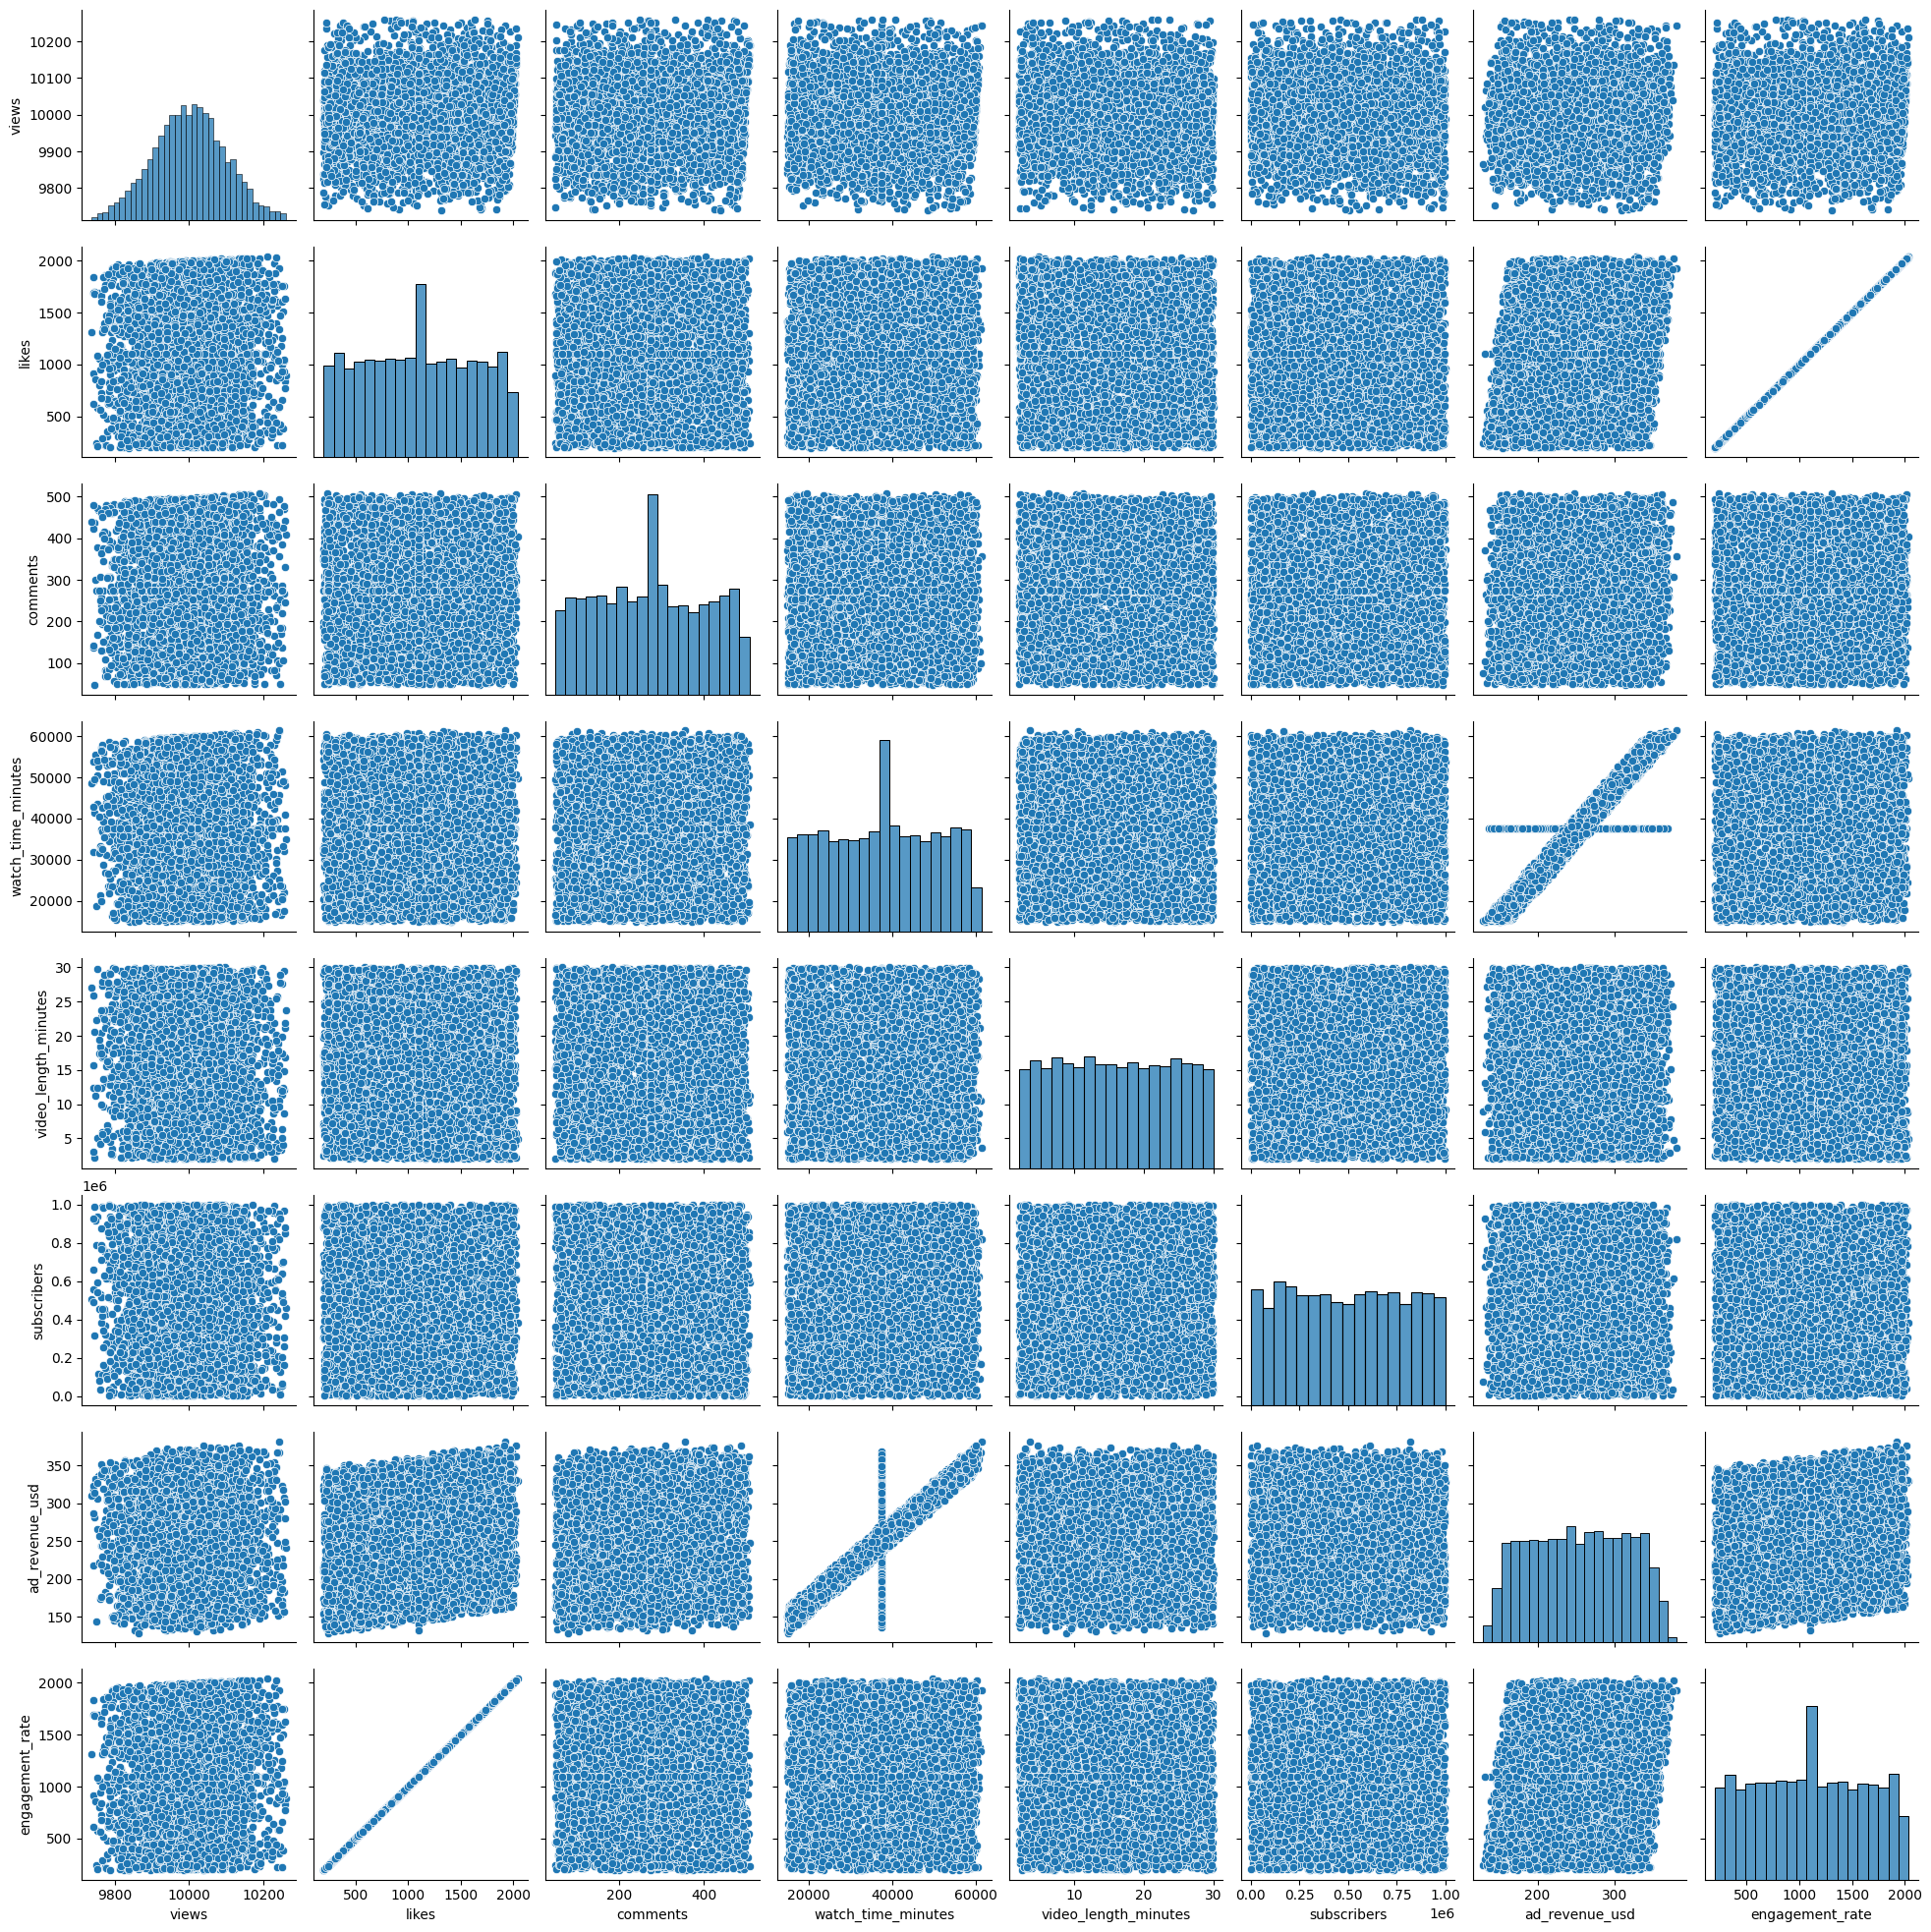

In [41]:
sns.pairplot(df.select_dtypes(include=["number"]))
plt.show()

In [42]:
x=df[["views","likes","comments","subscribers","engagement_rate"]]
y=df["ad_revenue_usd"]

In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [45]:
print(x_train_scaled)
print(x_test_scaled)

[[ 0.72553942  0.46536703  0.57861878 -0.96399884  0.46538081]
 [-2.25872962 -0.70154454 -0.7074101  -1.60339986 -0.70156116]
 [-0.56971624  1.36163356  1.70587866 -0.98351178  1.36167612]
 ...
 [-0.42464761 -0.93296566  0.07849643 -1.16968236 -0.93296343]
 [ 0.6530051  -1.17615396 -0.9614405  -0.84405253 -1.1761778 ]
 [ 1.67884759  0.27513102 -1.18371709  1.08185329  0.27510137]]
[[-0.19668261 -0.08965142  0.95172592 -1.58531604 -0.08962776]
 [-1.6370069  -0.62898029  1.38834066  1.69642972 -0.62894455]
 [-0.22776875  1.54010239  1.7773247   1.26418634  1.54014638]
 ...
 [ 0.69445329 -1.12320167  1.46772516 -0.02897272 -1.12316593]
 [ 0.27997147  0.03194273  0.36428063 -0.32829347  0.03195155]
 [ 1.48196873  0.34965647 -1.19165554 -1.01984205  0.34962666]]


model training


In [48]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)



In [50]:

from sklearn.tree import DecisionTreeRegressor
dtr =  DecisionTreeRegressor(random_state = 42)
dtr.fit(x_train,y_train)

y_pred_dtr = dtr.predict(x_test)

In [51]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)
rfr.fit(x_train,y_train)

y_pred_rfr = rfr.predict(x_test)

In [52]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)

y_pred_knn = knn.predict(x_test)


In [53]:
from sklearn.neural_network import MLPRegressor
mlp = MLPRegressor(random_state=42)
mlp.fit(x_train,y_train)

y_pred_mlp = mlp.predict(x_test)

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [59]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

model validation

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Linear Regression R2 Score:", r2_score(y_test, y_pred))
print("Decision Tree Regressor R2 Score:", r2_score(y_test, y_pred_dtr))
print("Random Forest Regressor R2 Score:", r2_score(y_test, y_pred_rfr))
print("K-Nearest Neighbors Regressor R2 Score:", r2_score(y_test, y_pred_knn))
print("MLP Regressor R2 Score:", r2_score(y_test, y_pred_mlp))



Linear Regression R2 Score: 0.03663014453843716
Decision Tree Regressor R2 Score: -0.9743631604244842
Random Forest Regressor R2 Score: -0.03898511356031009
K-Nearest Neighbors Regressor R2 Score: -0.18136057811045836
MLP Regressor R2 Score: 0.02723484186792391


converting into pickle file

In [61]:
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']